группа 0 - неинтересные для маркетинга клиенты (например, низкий доход или молодой возраст)  
группа 1 - потенциально интересные клиенты (например, высокий доход или зрелый возраст)

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)
age = np.random.randint(18, 70, size=100)
income = np.random.randint(20000, 100000, size=100)

# метки
# labels = np.where((age > 30) & (income > 50000), 1, 0)
labels = np.array([1 if (a > 30 and i > 50000) else 0 for a, i in zip(age, income)])

# dataframe
data = pd.DataFrame({'age': age, 'income': income, 'label': labels})
print(data.head())

   age  income  label
0   56   81228      1
1   69   68984      1
2   46   60774      1
3   32   22568      0
4   60   82592      1


In [2]:
from sklearn.model_selection import train_test_split

X = data[['age', 'income']].values
y = data['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 80
Test set size: 20


In [9]:
# простая нейронная сесть с 2 слоями

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense


# 1 слой - 16 нейронов, функция активации ReLU которая пропускает только положительные значения и обнуляет отрицательные, входной слой с 2 признаками (возраст и доход)
# выходной слой - 1 нейрон, функция активации сигмоида которая возвращает значение от 0 до 1, что подходит для бинарной классификации (принадлежность объекта к классу)
model = Sequential([
    # Dense(16, activation='relu', input_shape=(2,)),
    Dense(16, activation='relu', input_dim = 2),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

# настройки модели перед обучением 
# (adam подстраивается под данные в процессе обучения)
# (binary_crossentropy измеряет насколько предсказанные значения отличаются от реальных)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print(model.summary())

C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 16)                  │              48 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [10]:
# fit - основная команда, которая запускает процесс обучения модели,
# она позволяет модели пройтись по всем данным чтобы настроить свои параметры (веса и смещения) для минимизации ошибки
# epochs - количество проходов по всем данным, чем больше тем лучше, но может привести к переобучению

history = model.fit(X_train, y_train, epochs=20, batch_size=8, validation_split=0.2, verbose=1)

# вместо того чтобы обрабатывать все данные сразу, модель делит их на группы (batch_size=8),
# это помогает оптимизировать вычисления и ускорить обучение, особенно на больших наборах данных

# переменная history сохраняет информацию о процессе обучения модели, включая значения потерь и точности на каждой эпохе, что позволяет анализировать эффективность модели и выявлять проблемы переобучения или недообучения


Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.4219 - loss: 2095.4998 - val_accuracy: 0.6250 - val_loss: 911.1950
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4219 - loss: 815.5438 - val_accuracy: 0.6250 - val_loss: 135.8549
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6094 - loss: 298.7758 - val_accuracy: 0.3750 - val_loss: 719.8135
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5469 - loss: 308.2594 - val_accuracy: 0.6250 - val_loss: 50.1111
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4219 - loss: 125.3361 - val_accuracy: 0.6250 - val_loss: 10.9400
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5469 - loss: 60.0575 - val_accuracy: 0.6250 - val_loss: 36.9480
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5156 - loss: 30.7324 - val_accuracy: 0.6250 - val_loss: 17.6178
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4844 - loss: 33.7639 - val_accuracy: 0.

In [11]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.8000 - loss: 0.7729
Test Loss: 0.7729
Test Accuracy: 0.8000


In [12]:
# вероятность принадлежности клиентов 

predictions = model.predict(X_test)

predicted_classes = (predictions > 0.5).astype(int)

comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': predicted_classes.flatten()})
print(comparison_df.head(10))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
   Actual  Predicted
0       1          1
1       1          1
2       0          0
3       0          1
4       1          1
5       1          0
6       1          1
7       1          1
8       0          1
9       1          1


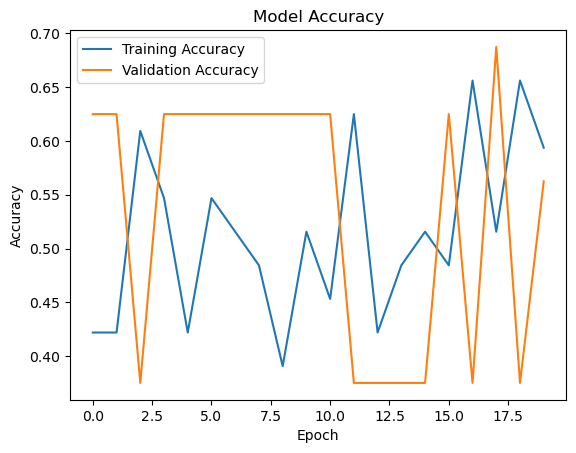

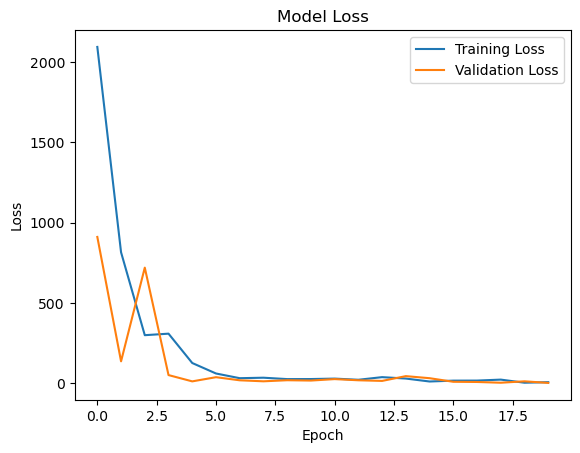

In [13]:
# графики точности и потерь

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()